In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [101]:
df = pd.read_csv('/content/fertilizer_recommendation.csv')
df.shape

(10000, 20)

In [102]:
df.sample(10)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
5932,Silt,5.34,41.69,1.46,2.69,123,42,119,36.83,50.64,2541.49,Potato,Vegetative,Zaid,Drip,Maize,South,150.24,2.08,Compost
9580,Loamy,6.43,35.20,1.38,2.60,93,47,89,23.58,63.91,604.91,Cotton,Sowing,Zaid,Sprinkler,Tomato,South,67.40,5.47,DAP
9770,Clay,7.94,24.95,0.26,0.48,156,44,19,14.15,77.43,2521.77,Wheat,Harvest,Kharif,Sprinkler,Cotton,West,152.76,4.73,MOP
5933,Silt,7.60,45.86,0.24,1.57,156,46,69,20.03,65.85,900.01,Potato,Harvest,Kharif,Canal,Maize,South,289.22,2.63,Compost
6123,Silt,7.04,49.87,0.67,0.46,102,33,101,32.48,83.92,914.37,Sugarcane,Vegetative,Rabi,Drip,Sugarcane,East,134.29,3.19,DAP
7467,Clay,5.05,58.28,0.40,2.52,150,61,118,22.77,34.12,639.03,Rice,Flowering,Zaid,Drip,Sugarcane,East,217.45,2.78,Compost
4416,Clay,6.89,24.21,0.57,0.82,37,47,58,24.95,35.02,1984.76,Tomato,Vegetative,Zaid,Canal,Potato,West,164.53,3.61,Urea
4067,Sandy,6.52,19.44,1.42,3.00,142,11,85,14.58,73.33,2542.45,Wheat,Vegetative,Zaid,Drip,Sugarcane,Central,146.28,7.23,DAP
2881,Sandy,6.33,50.38,1.03,0.92,39,44,40,37.64,37.70,1774.95,Maize,Sowing,Rabi,Drip,Tomato,North,208.41,2.66,Urea
6956,Silt,7.21,55.68,0.84,2.28,135,66,32,33.84,33.52,1666.90,Wheat,Harvest,Zaid,Rainfed,Rice,East,158.97,5.95,MOP


In [103]:
keep_cols = [
    'Soil_Type', 'Soil_pH', 'Soil_Moisture',
    'Organic_Carbon','Nitrogen_Level', 'Phosphorus_Level',
    'Potassium_Level','Temperature', 'Humidity',
    'Rainfall','Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type','Recommended_Fertilizer']
df = df[keep_cols]
df.shape

(10000, 15)

In [104]:
df.sample(10)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Recommended_Fertilizer
6748,Clay,5.48,15.16,1.30,34,67,96,21.35,77.31,608.96,Cotton,Vegetative,Rabi,Drip,Urea
8240,Silt,5.44,43.08,1.24,39,24,62,18.40,83.29,612.78,Sugarcane,Vegetative,Zaid,Drip,Urea
4537,Clay,7.60,47.56,0.61,29,50,103,30.25,76.52,1778.68,Wheat,Harvest,Kharif,Canal,Urea
1931,Silt,4.87,25.75,0.23,95,89,88,39.47,66.03,2973.49,Cotton,Sowing,Kharif,Drip,Compost
1400,Clay,7.24,39.10,0.81,137,11,89,14.04,74.65,1881.47,Sugarcane,Sowing,Rabi,Drip,DAP
9162,Loamy,7.35,48.94,0.97,45,60,47,35.41,76.29,2527.24,Potato,Flowering,Zaid,Drip,Urea
1036,Silt,7.35,29.09,0.45,96,57,22,16.57,47.54,2620.63,Rice,Harvest,Kharif,Sprinkler,MOP
9984,Loamy,7.54,26.74,0.72,63,74,54,37.11,67.67,1972.29,Wheat,Sowing,Zaid,Drip,Urea
7362,Clay,7.03,56.03,0.30,100,31,59,14.05,43.59,291.05,Rice,Sowing,Zaid,Rainfed,DAP
2164,Loamy,7.34,54.91,1.26,64,84,100,37.83,85.72,1661.96,Rice,Sowing,Zaid,Drip,Urea


In [105]:
df['Recommended_Fertilizer'].value_counts()

,count
Recommended_Fertilizer,
Urea,3101
DAP,2920
MOP,1408
Compost,996
Zinc Sulphate,752
NPK,641
SSP,182


In [106]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('Recommended_Fertilizer',axis=1),
df['Recommended_Fertilizer'],test_size=0.2,random_state=42)

In [107]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [108]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type']
numeric_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
                 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level',
                 'Temperature', 'Humidity', 'Rainfall']

ct = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

x_train = ct.fit_transform(x_train)
x_test = ct.transform(x_test)

In [109]:
x_train.shape

(8000, 31)

In [110]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Dropout,Input

In [111]:
model = Sequential()
model.add(Input(shape=(31,)))
model.add(Dense(49, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(28, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(7, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 49)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 28)             │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           203 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,171 (12.39 KB)

 Trainable params: 3,171 (12.39 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
history = model.fit(x_train, y_train, validation_split=0.1, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5342 - loss: 1.2717 - val_accuracy: 0.7225 - val_loss: 0.8166
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7201 - loss: 0.8208 - val_accuracy: 0.7788 - val_loss: 0.6507
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7511 - loss: 0.7209 - val_accuracy: 0.8062 - val_loss: 0.5812
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7765 - loss: 0.6520 - val_accuracy: 0.8163 - val_loss: 0.5413
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7979 - loss: 0.5935 - val_accuracy: 0.8313 - val_loss: 0.5032
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8051 - loss: 0.5617 - val_accuracy: 0.8400 - val_loss: 0.4780
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8160 - loss: 0.5275 - val_accuracy: 0.8438 - val_loss: 0.4560
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8296 - loss: 0.4959 - val_accuracy: 0.

In [113]:
from sklearn.metrics import accuracy_score
y_pred = np.argmax(model.predict(x_test), axis=1)
accuracy_score(y_test, y_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


0.8675

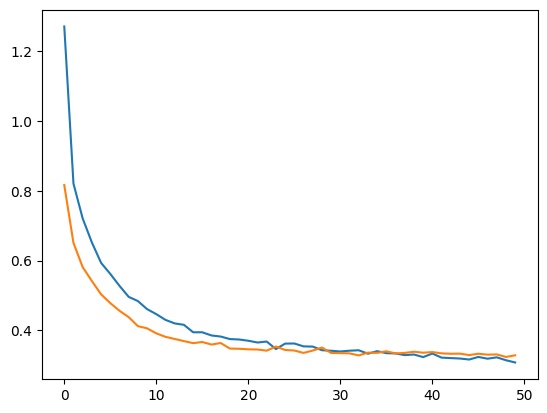

In [114]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

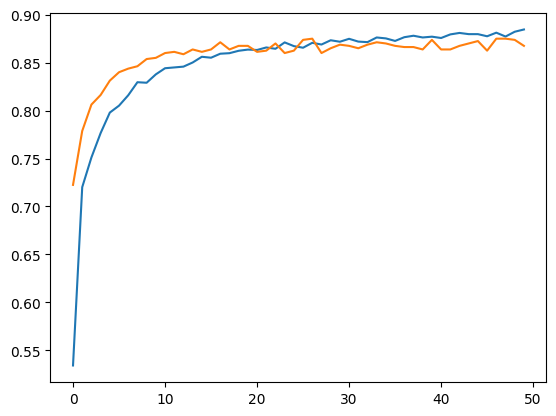

In [115]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [116]:
from keras.models import model_from_json
class FertilizerPipeline:
    def __init__(self, model, preprocessor, label_encoder):
        self.model_config = model.to_json()
        self.model_weights = model.get_weights()
        self.preprocessor = preprocessor
        self.label_encoder = label_encoder

    def predict(self, X):
        model = model_from_json(self.model_config)
        model.set_weights(self.model_weights)
        X_processed = self.preprocessor.transform(X)
        probs = model.predict(X_processed)
        idx = probs.argmax(axis=1)
        return self.label_encoder.inverse_transform(idx)

In [119]:
import joblib
pipeline = FertilizerPipeline(model=model, preprocessor=ct, label_encoder=le)
joblib.dump(pipeline, 'fertilizer_pipeline.pkl')

['fertilizer_pipeline.pkl']

In [118]:
loaded_pipeline = joblib.load('fertilizer_pipeline.pkl')

sample = pd.DataFrame([{
    'Soil_Type': 'Clay', 'Soil_pH': 6.5, 'Soil_Moisture': 30.0, 'Organic_Carbon': 1.2,
    'Nitrogen_Level': 80, 'Phosphorus_Level': 40, 'Potassium_Level': 45,
    'Temperature': 28.0, 'Humidity': 60.0, 'Rainfall': 120.0,
    'Crop_Type': 'Wheat', 'Crop_Growth_Stage': 'Vegetative', 'Season': 'Rabi', 'Irrigation_Type': 'Drip'
}])

result = loaded_pipeline.predict(sample)
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
['DAP']
